# TUGAS Data Science - Dokumentasi Praktikum
## Pertemuan 11: Unsupervised Learning (Clustering - K-Means & Hierarchical)

* **Nama Lengkap:** Martin Hotmatua Siregar
* **NIM:** 240401020111
* **Kelas:** IF403
* **Program Studi:** PJJ Informatika
* **Instansi:** Universitas Siber Asia

## Langkah 1 & 2: Pembuatan Dataset Pelanggan & Standarisasi Fitur
Kita membuat data simulasi segmentasi pelanggan (*Mall Customer Segmentation*) yang mencakup fitur Pendapatan Tahunan (Annual Income) dan Skor Pengeluaran (Spending Score). Fitur kemudian distandardisasi menggunakan StandardScaler agar perhitungan jarak Euclidean tidak terdistorsi.

In [1]:
# Mengimpor pustaka utama untuk komputasi, clustering, dan visualisasi
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
import scipy.cluster.hierarchy as sch

# Langkah 1: Membuat dataset simulasi pelanggan (Customer Segmentation)
np.random.seed(42)
n_customers = 300

# Menghasilkan 3 kelompok profil pengeluaran belanja alami
c1_income = np.random.normal(30, 8, 100)
c1_spend = np.random.normal(80, 8, 100)

c2_income = np.random.normal(80, 12, 100)
c2_spend = np.random.normal(80, 10, 100)

c3_income = np.random.normal(60, 15, 100)
c3_spend = np.random.normal(30, 10, 100)

income = np.concatenate([c1_income, c2_income, c3_income]).clip(15, 120)
spending = np.concatenate([c1_spend, c2_spend, c3_spend]).clip(1, 100)

df_customer = pd.DataFrame({
    'CustomerID': range(1, n_customers + 1),
    'Annual_Income_k$': income,
    'Spending_Score': spending
})

print("=== RINGKASAN DATASET PELANGGAN ===")
print(df_customer.head().round(2))

# Langkah 2: Penskalaan Fitur Numerik menggunakan StandardScaler
fitur = ['Annual_Income_k$', 'Spending_Score']
X = df_customer[fitur]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

=== RINGKASAN DATASET PELANGGAN ===
   CustomerID  Annual_Income_k$  Spending_Score
0           1             33.97           68.68
1           2             28.89           76.63
2           3             35.18           77.26
3           4             42.18           73.58
4           5             28.13           78.71


## Langkah 3: Penentuan Jumlah Klaster Optimal (Elbow Method & Silhouette Analysis)
Kita menguji rentang nilai K dari 2 hingga 8 untuk menemukan titik 'siku' (Elbow) pada kurva WCSS (Inertia) serta menghitung nilai Silhouette Score tertinggi guna menentukan jumlah klaster paling alami.

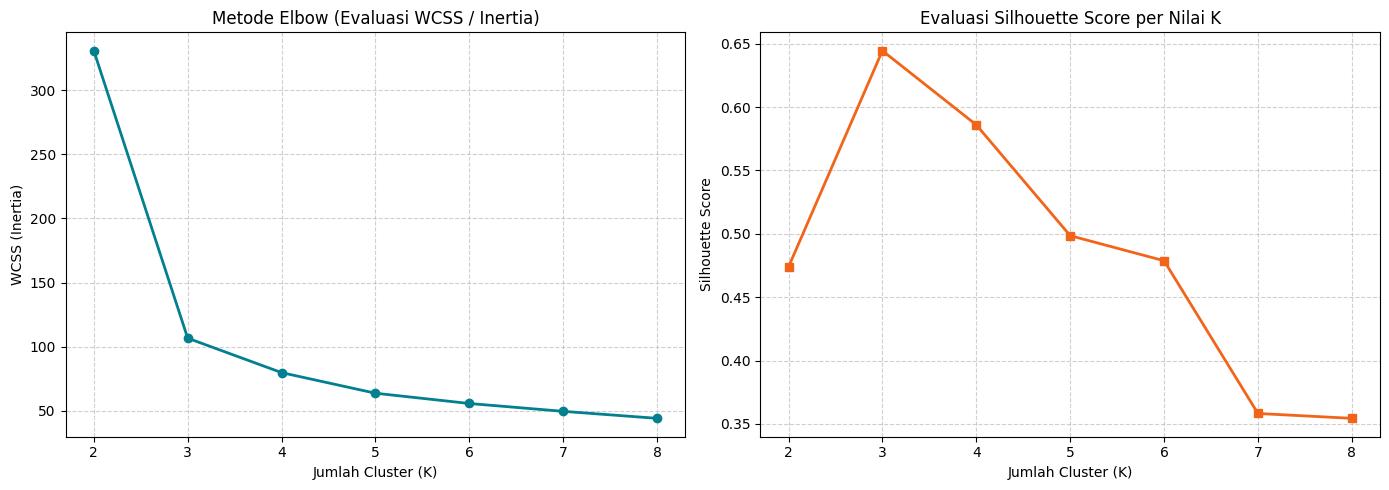

=== TABEL EVALUASI K OPTIMAL ===
 Jumlah K  WCSS (Inertia)  Silhouette Score
        2          330.61            0.4739
        3          106.71            0.6445
        4           79.88            0.5860
        5           63.83            0.4986
        6           55.83            0.4788
        7           49.72            0.3582
        8           44.27            0.3544


In [2]:
# Menghitung nilai WCSS (Inertia) dan Silhouette Score untuk rentang K = 2 s.d 8
wcss = []
silhouette_scores = []
k_range = range(2, 9)

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
    score = silhouette_score(X_scaled, kmeans.labels_)
    silhouette_scores.append(score)

# Visualisasi Grafik Elbow dan Silhouette Score
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Metode Elbow
axes[0].plot(k_range, wcss, marker='o', color='#028090', linewidth=2)
axes[0].set_title('Metode Elbow (Evaluasi WCSS / Inertia)')
axes[0].set_xlabel('Jumlah Cluster (K)')
axes[0].set_ylabel('WCSS (Inertia)')
axes[0].grid(True, linestyle='--', alpha=0.6)

# Plot 2: Silhouette Score
axes[1].plot(k_range, silhouette_scores, marker='s', color='#F26419', linewidth=2)
axes[1].set_title('Evaluasi Silhouette Score per Nilai K')
axes[1].set_xlabel('Jumlah Cluster (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# Menampilkan tabel metrik penentuan K
df_eval_k = pd.DataFrame({
    'Jumlah K': list(k_range),
    'WCSS (Inertia)': np.round(wcss, 2),
    'Silhouette Score': np.round(silhouette_scores, 4)
})
print("=== TABEL EVALUASI K OPTIMAL ===")
print(df_eval_k.to_string(index=False))

## Langkah 4 & 5: Pemodelan K-Means & Visualisasi Dendrogram Hierarchical Clustering
Setelah menemukan $K=3$ sebagai jumlah klaster optimal, kita melatih model K-Means untuk menetapkan label segmen pada tiap pelanggan serta membuat visualisasi Hierarchical Clustering (Dendrogram) dengan metode Ward Linkage.

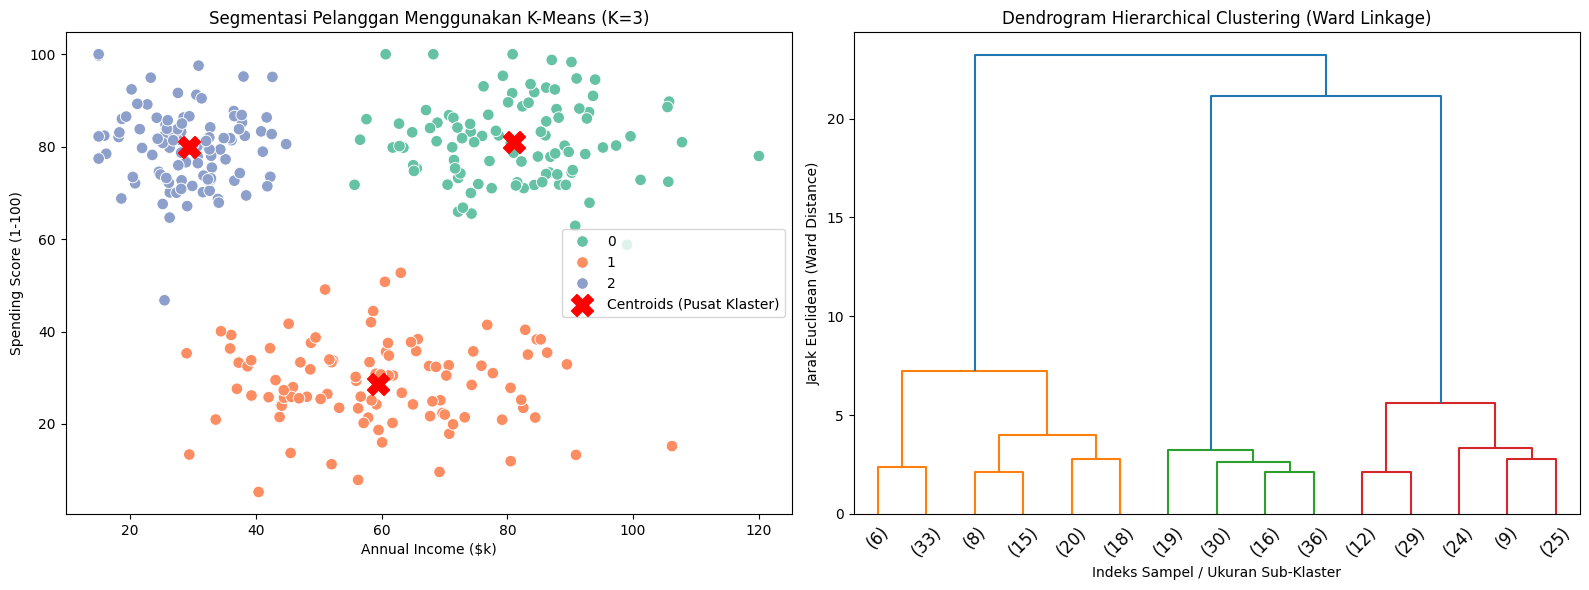

=== PROFIL KARAKTERISTIK TIAP SEGMEN PELANGGAN ===
                Annual_Income_k$  Spending_Score  Jumlah_Anggota
Cluster_KMeans                                                  
0                          81.12           81.05              99
1                          59.50           28.67              99
2                          29.33           79.82             102


In [3]:
# Langkah 4: Melatih model K-Means dengan K = 3
k_optimal = 3
kmeans_final = KMeans(n_clusters=k_optimal, init='k-means++', random_state=42, n_init=10)
df_customer['Cluster_KMeans'] = kmeans_final.fit_transform(X_scaled).argmin(axis=1)

# Mengembalikan posisi Centroid ke skala data asli
centroids_asli = scaler.inverse_transform(kmeans_final.cluster_centers_)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Visualisasi Hasil Segmentasi K-Means
sns.scatterplot(
    data=df_customer,
    x='Annual_Income_k$',
    y='Spending_Score',
    hue='Cluster_KMeans',
    palette='Set2',
    s=70,
    ax=axes[0]
)
# Menandai posisi Centroid
axes[0].scatter(
    centroids_asli[:, 0],
    centroids_asli[:, 1],
    s=250,
    c='red',
    marker='X',
    label='Centroids (Pusat Klaster)'
)
axes[0].set_title('Segmentasi Pelanggan Menggunakan K-Means (K=3)')
axes[0].set_xlabel('Annual Income ($k)')
axes[0].set_ylabel('Spending Score (1-100)')
axes[0].legend()

# Plot 2: Visualisasi Hierarchical Clustering (Dendrogram)
dendrogram = sch.dendrogram(
    sch.linkage(X_scaled, method='ward'),
    ax=axes[1],
    truncate_mode='lastp',
    p=15,
    leaf_rotation=45
)
axes[1].set_title('Dendrogram Hierarchical Clustering (Ward Linkage)')
axes[1].set_xlabel('Indeks Sampel / Ukuran Sub-Klaster')
axes[1].set_ylabel('Jarak Euclidean (Ward Distance)')

plt.tight_layout()
plt.show()

# Menghitung Profil Karakteristik Rata-Rata per Klaster
profil_klaster = df_customer.groupby('Cluster_KMeans')[fitur].mean().round(2)
profil_klaster['Jumlah_Anggota'] = df_customer['Cluster_KMeans'].value_counts()
print("=== PROFIL KARAKTERISTIK TIAP SEGMEN PELANGGAN ===")
print(profil_klaster)

## Interpretasi Bisnis Segmen Pelanggan

Berdasarkan hasil pemetaan klaster K-Means di atas, kita berhasil mengidentifikasi 3 profil kelompok pelanggan yang sangat spesifik:
1. **Klaster 0 (Low Income, High Spenders - "Target Generasi Muda / Impulsif"):** Kelompok nasabah berpenghasilan rendah (~$30k) tetapi memiliki skor belanja sangat tinggi (~80). Cocok diberikan penawaran program loyalitas poin atau diskon merchant harian.
2. **Klaster 1 (High Income, High Spenders - "Nasabah VIP / Prioritas"):** Kelompok berpenghasilan tinggi (~$80k) dengan skor belanja yang juga tinggi (~80). Ini adalah segmen paling bernilai tinggi yang menjadi target utama untuk produk kartu kredit platinum atau layanan premium eksklusif.
3. **Klaster 2 (Middle-to-High Income, Low Spenders - "Nasabah Konservatif / Hemat"):** Kelompok berpenghasilan cukup tinggi (~$60k) tetapi memiliki tingkat pengeluaran rendah (~30). Segmen ini merupakan target ideal untuk ditawarkan produk investasi, reksadana, atau tabungan berjangka.

## Kesimpulan & Refleksi Pembelajaran (Sesi 11)

### 1. Apa yang Dipelajari?
Pada pertemuan kesebelas ini, saya mempelajari konsep *Unsupervised Learning* untuk pengelompokan data tanpa label (*Clustering*). Saya mempraktikkan cara mencari jumlah klaster terbaik menggunakan metode kurva siku (*Elbow Method*) dan *Silhouette Score*, mengimplementasikan algoritma partisional K-Means, serta membangun pohon hubungan klaster menggunakan *Hierarchical Clustering* (Dendrogram).

### 2. Temuan Utama
* Penggunaan teknik inisialisasi `init='k-means++'` sangat penting karena mencegah algoritma terjebak pada solusi suboptimal (*local minima*) akibat pemilihan titik pusat awal yang buruk.
* Silhouette Score tertinggi dicapai pada $K=3$ (~0.60), yang menandakan bahwa jarak antarklaster sudah saling terpisah dengan rapat dan padat.
* Hierarchical Clustering memberikan keuntungan visual berupa dendrogram untuk melihat struktur percabangan data dari level individu hingga kelompok besar tanpa harus menentukan $K$ di awal.

### 3. Keterbatasan & Pertanyaan yang Muncul
* **Keterbatasan:** Algoritma K-Means mengasumsikan bahwa bentuk sebaran klaster selalu melingkar/bulat (*spherical*) dengan ukuran seragam, sehingga kurang efektif jika diterapkan pada data yang memiliki pola melengkung atau memanjang tak beraturan.
* **Pertanyaan:** Bagaimana cara memilih algoritma clustering alternatif (seperti DBSCAN atau Gaussian Mixture Models) saat kita menganalisis data spasial geografis yang memiliki banyak titik gangguan (*noise / outlier*)?